Dataset Shape: (13, 15)

First 5 rows with labels:
                                          lemmatized  label
0  product arrive time packaging great quality am...      1
1                                 product amaze love      1
2                 buy phone hz display totally worth      1
3                  wow product awesome bit expensive      1
4                         laptop work perfectly fine      1
NAIVE BAYES MODEL EVALUATION
Accuracy:  0.80
Precision: 0.80
Recall:    1.00
F1-Score:  0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.80      1.00      0.89         4

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



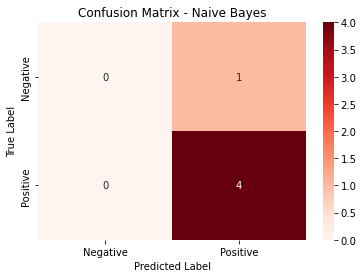

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# 1. Load the Data
# Using the file provided in the exercise
df = pd.read_csv('Processed_Reviews.csv')

# 2. Manually Label the Data
# Creating a list of labels based on the review content
# 1 = Positive, 0 = Negative
labels = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
df['label'] = labels

# Display shape and head to follow Lab 6 EDA style
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows with labels:")
print(df[['lemmatized', 'label']].head())

# 3. Pre-processing
# Using only the lemmatized column as per instructions
X = df['lemmatized']
y = df['label']

# 4. Vectorization
# Applying TfidfVectorizer to transform the text data into numerical features
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

# 5. Model Training
# Split the data into training and test sets (using 33% test size as common in labs)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.33, random_state=42)

# Train a Naïve Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 6. Evaluation
# Make predictions
predictions = nb_model.predict(X_test)

# Calculate Evaluation Metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions, zero_division=0)
recall = metrics.recall_score(y_test, predictions, zero_division=0)
f1 = metrics.f1_score(y_test, predictions, zero_division=0)

print("NAIVE BAYES MODEL EVALUATION")
print("="*30)
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Display Classification Report
print("\nClassification Report:")
print(metrics.classification_report(y_test, predictions, zero_division=0))

# Display Confusion Matrix
cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()